In [1]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import pandas as pd
import preprocess
import seaborn as sns

In [2]:
df_raw = pd.read_csv("malicious_url.csv")

# Concat trực tiếp: Bảng gốc + Bảng features
df = pd.concat([
    df_raw.reset_index(drop=True), 
    pd.DataFrame(df_raw['url'].apply(preprocess.extract_all_features).tolist()).reset_index(drop=True)
], axis=1)

In [3]:
def generate_wordCloud(df):
    url = ' '.join(i for i in df.url)
    wordcloud = WordCloud(width=1000, height=500, colormap='Paired').generate(url)
    plt.figure(figsize=(8, 5), facecolor='k')
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.show()

In [4]:
# Create dataframes for each type of URL
df_benign = df[df.type == 'benign']
df_defacement = df[df.type == 'defacement']
df_phishing = df[df.type == 'phishing']
df_malware = df[df.type == 'malware']

WordCloud for Benign url


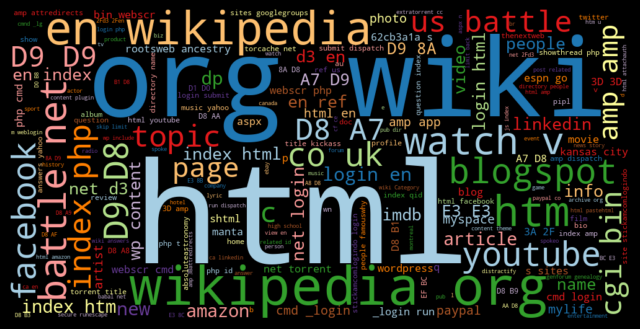

WordCloud for Defacement url


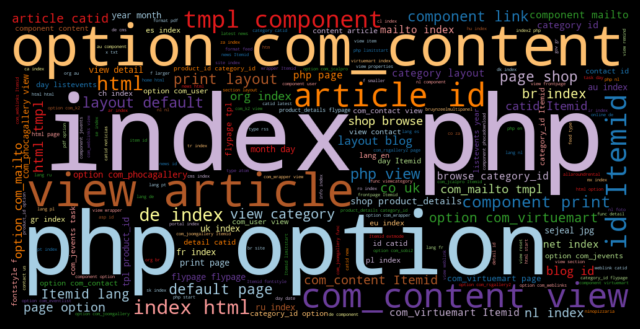

WordCloud for Phishing url


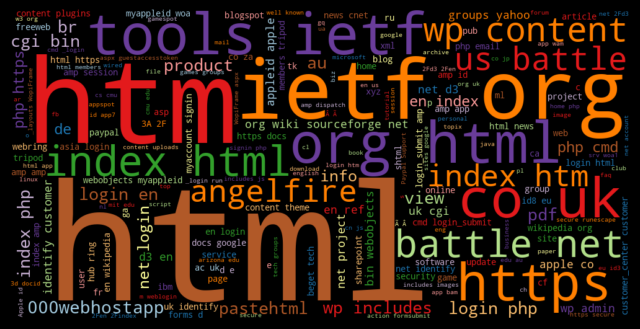

WordCloud for Malware url


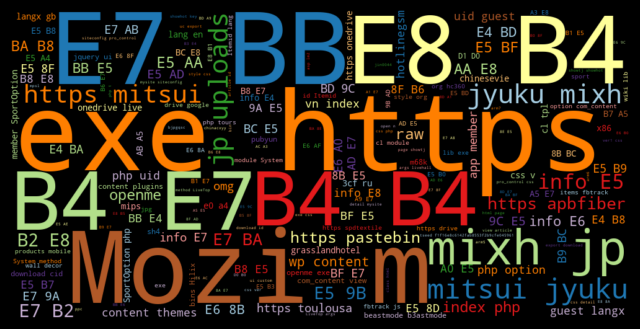

In [5]:
# WordCloud for benign
print('WordCloud for Benign url')
generate_wordCloud(df_benign)

print('WordCloud for Defacement url')
generate_wordCloud(df_defacement)

print('WordCloud for Phishing url')
generate_wordCloud(df_phishing)

print('WordCloud for Malware url')
generate_wordCloud(df_malware)

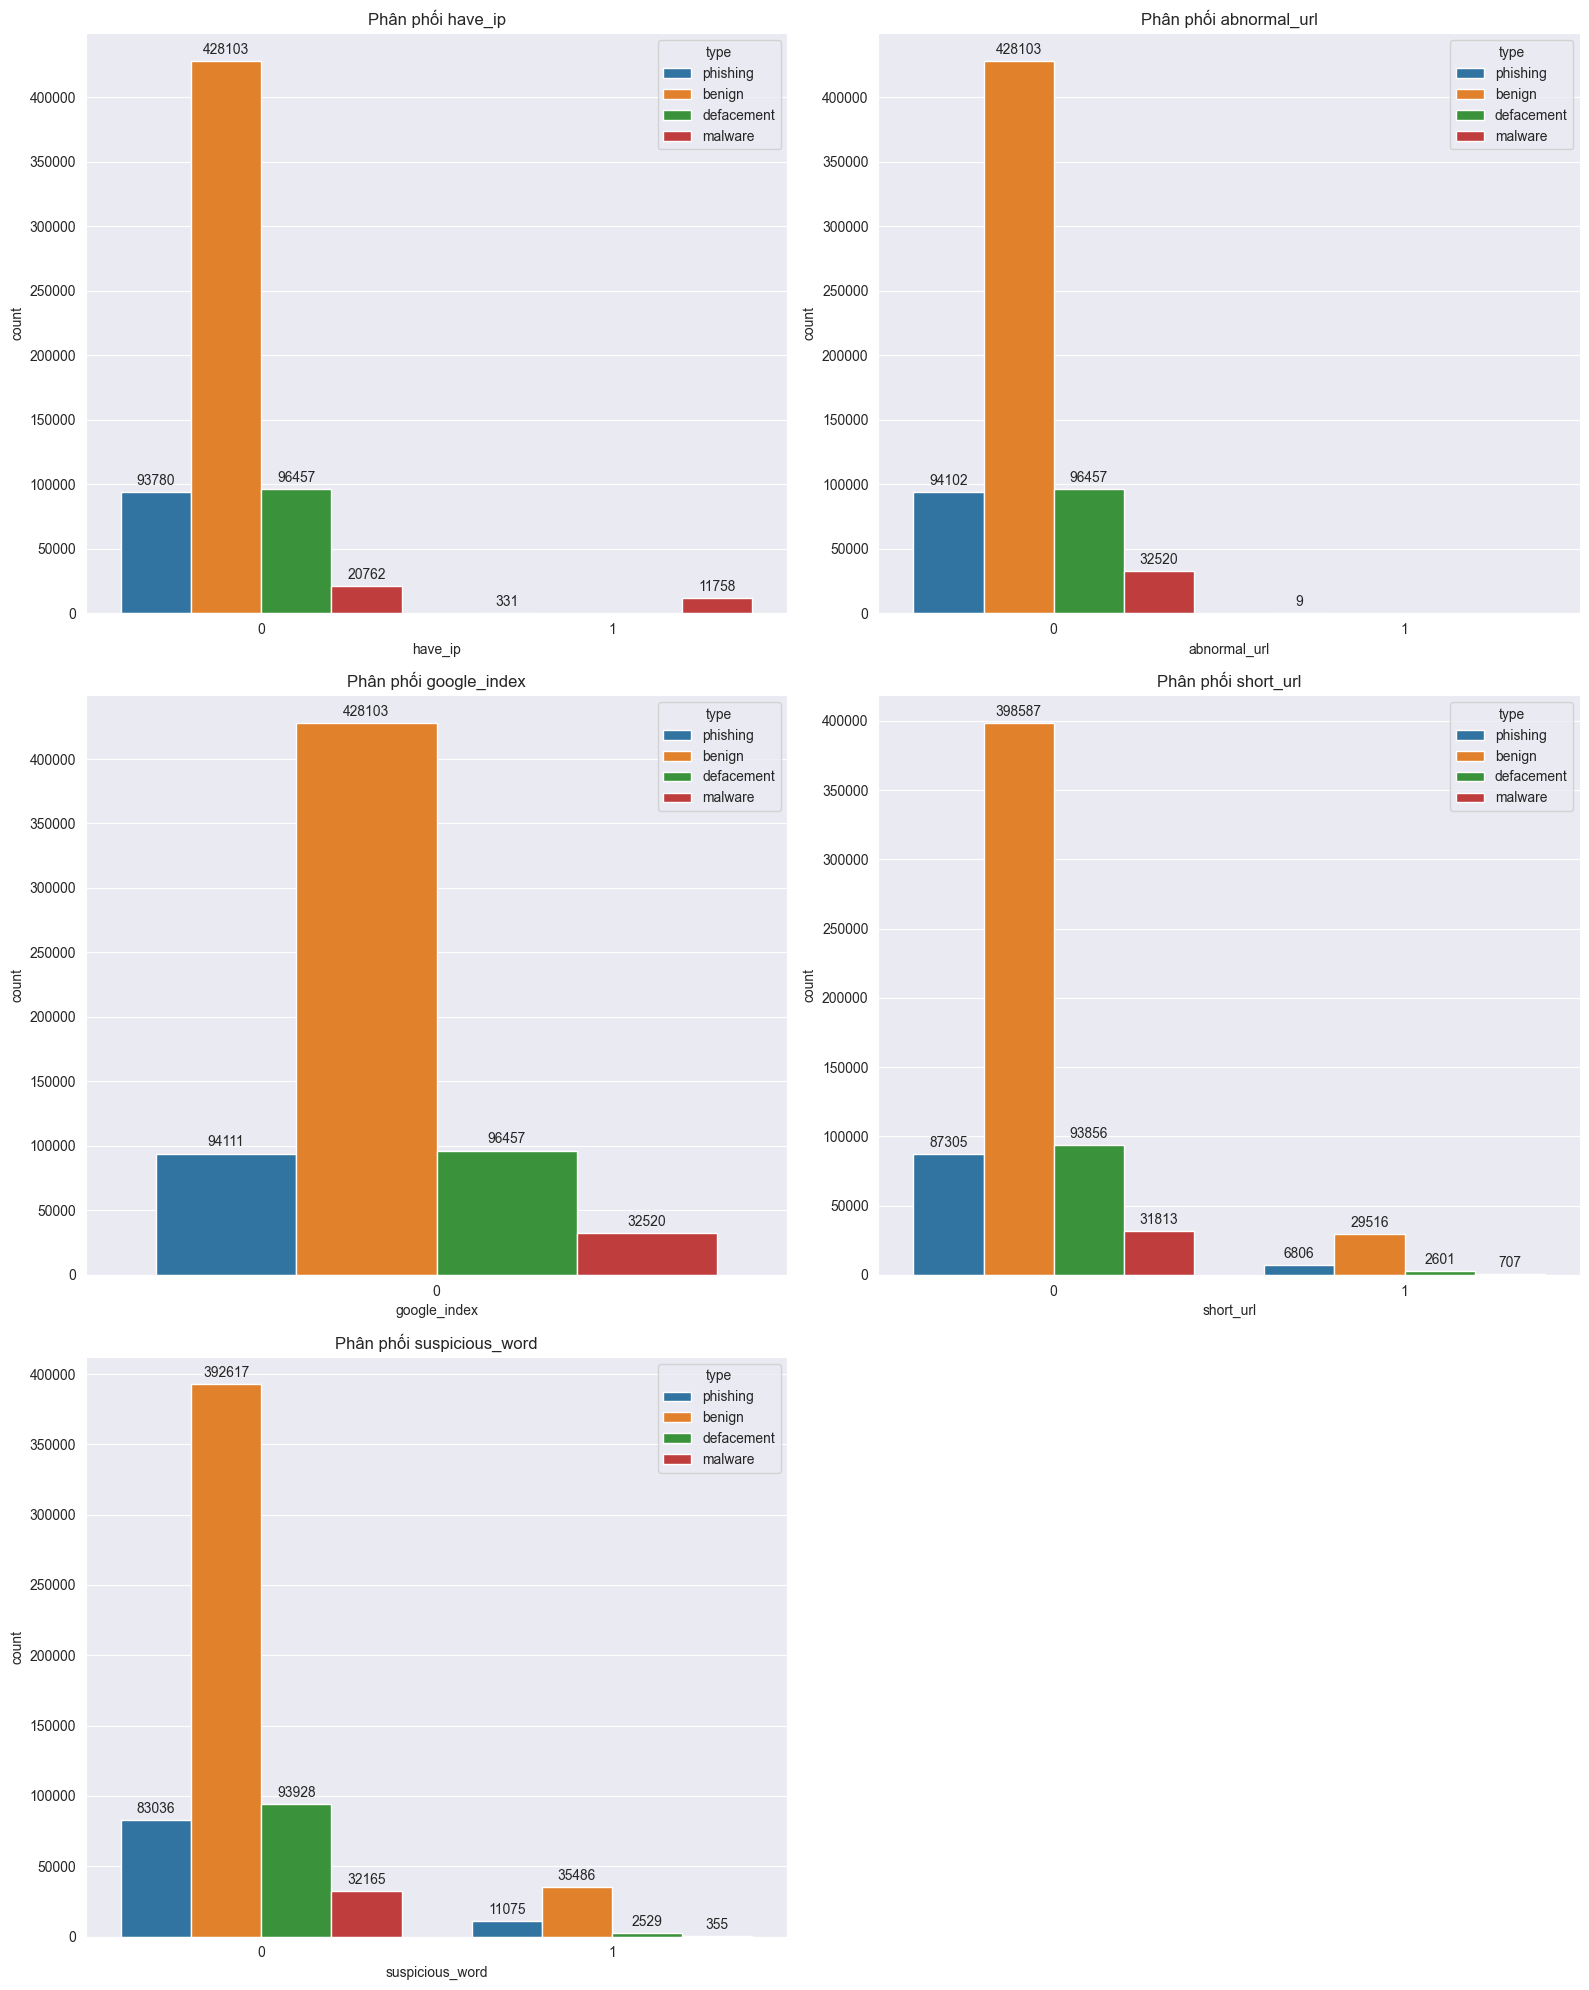

In [6]:
# Danh sách tất cả các cột binary (0/1) bạn muốn vẽ
# Thay đổi list này theo các cột trong dataframe của bạn
binary_cols = [
    'have_ip',
    'abnormal_url',
    'google_index',
    'short_url',          # URL rút gọn
    'suspicious_word'   # Có từ đáng ngờ
]

# Thiết lập style
sns.set_style('darkgrid')

# Binary
plt.figure(figsize=(16, 20))
for i, col in enumerate(binary_cols, 1):
    ax = plt.subplot(3, 2, i)
    sns.countplot(data=df, x=col, hue='type', ax=ax)
    plt.title(f'Phân phối {col}')
    for container in ax.containers:
        ax.bar_label(container, padding=3)
plt.tight_layout()
plt.show()



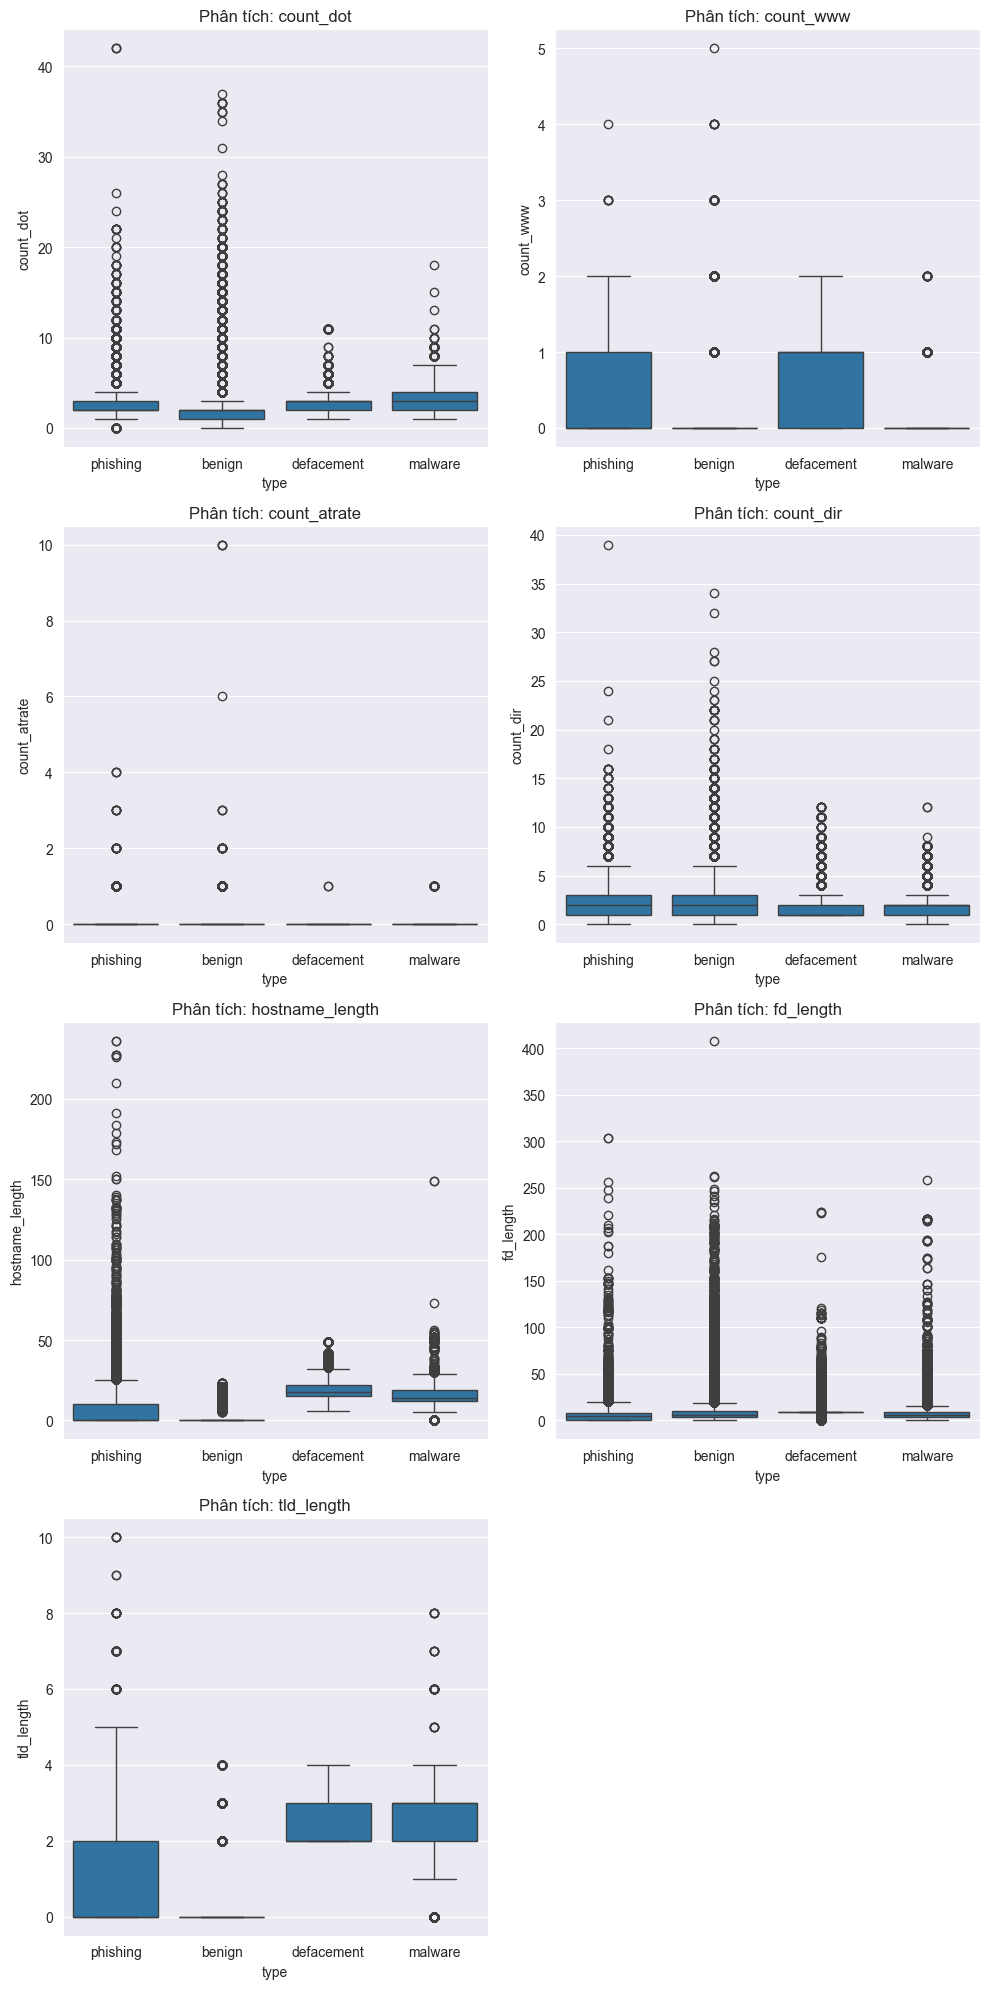

In [7]:
continuous_cols = [
    'count_dot',
    'count_www',
    'count_atrate',
    'count_dir',
    'hostname_length',
    'fd_length',
    'tld_length'
]

plt.figure(figsize=(10, 20))
for i, col in enumerate(continuous_cols, 1):
    ax = plt.subplot(4, 2, i)
    # Vẽ boxplot
    sns.boxplot(data=df, x='type', y=col, ax=ax)
    plt.title(f'Phân tích: {col}')

plt.tight_layout()
plt.show()

In [8]:
# Trong Notebook EDA
import preprocess
import pandas as pd

df_raw = pd.read_csv("malicious_url.csv")
# Trích xuất lại từ đầu để đảm bảo các cột ratio và entropy được tính đúng
X_new = pd.DataFrame(df_raw['url'].apply(preprocess.extract_all_features).tolist())
df_final = pd.concat([df_raw[['url', 'type']].reset_index(drop=True), X_new.reset_index(drop=True)], axis=1)

# KIỂM TRA: Soi xem các link ngắn trong tập dữ liệu đang được gán nhãn gì
print(df_final[df_final['url_length'] < 25][['url', 'type']].head(10))

# Lưu đè file cũ để Notebook Train có dữ liệu mới nhất
df_final.to_csv("processed_url_data.csv", index=False)

                         url      type
0           br-icloud.com.br  phishing
44           infinitysw.com/    benign
54                   ceu.hu/    benign
57        sunshinemills.com/    benign
62  veoox.com/tags/game.html    benign
64       aerosolesshoes.org/    benign
72      retajconsultancy.com  phishing
83     mccall-idchamber.org/    benign
89    spokeo.com/John+Collet    benign
94       alexpay2.beget.tech  phishing
